In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy


In [146]:
import os

os.getcwd()

'/Users/martadujella/Code/DataProjects/Sika/ParticlesMeasurmentKloten'

In [147]:

# Load the data
# Datasets describing the pollutants and meteorological data
# from 2020 to 2023
meteo2020_df = pd.read_csv('Data/KTZH_00002383_00005465.csv')
meteo2021_df = pd.read_csv('Data/KTZH_00002383_00005466.csv')
meteo2022_df = pd.read_csv('Data/KTZH_00002383_00005467.csv')
meteo2023_df = pd.read_csv('Data/KTZH_00002383_00005468.csv')

# Datasets describing the number-size distribution of the particles
# from 2020 to 2023
particles2020_df = pd.read_csv('Data/KTZH_00002383_00005469.csv')
particles2021_df = pd.read_csv('Data/KTZH_00002383_00005470.csv')
particles2022_df = pd.read_csv('Data/KTZH_00002383_00005471.csv')
particles2023_df = pd.read_csv('Data/KTZH_00002383_00005472.csv')

In [148]:
display(meteo2020_df)

,starttime,parameter,value,unit
0,2020-02-29T00:00:00+01:00,PN[5-100nm],9327.004028,#/cm3
1,2020-02-29T00:10:00+01:00,PN[5-100nm],14840.605862,#/cm3
2,2020-02-29T00:20:00+01:00,PN[5-100nm],12774.305916,#/cm3
3,2020-02-29T00:30:00+01:00,PN[5-100nm],12722.598825,#/cm3
4,2020-02-29T00:40:00+01:00,PN[5-100nm],13248.286614,#/cm3
...,...,...,...,...
707323,2020-12-31T23:10:00+01:00,Hr_Trockner,14.900000,%
707324,2020-12-31T23:20:00+01:00,Hr_Trockner,15.800000,%
707325,2020-12-31T23:30:00+01:00,Hr_Trockner,16.400000,%
707326,2020-12-31T23:40:00+01:00,Hr_Trockner,15.600000,%


In [149]:
display(particles2020_df)

,starttime,dp,parameter,value
0,2020-02-29T00:00:00+01:00,4.96,dN,317.782275
1,2020-02-29T00:00:00+01:00,5.14,dN,228.808446
2,2020-02-29T00:00:00+01:00,5.33,dN,346.173648
3,2020-02-29T00:00:00+01:00,5.52,dN,207.719798
4,2020-02-29T00:00:00+01:00,5.73,dN,174.466491
...,...,...,...,...
7515355,2020-12-31T23:50:00+01:00,88.17,dN/dlogDp,26491.549316
7515356,2020-12-31T23:50:00+01:00,91.40,dN/dlogDp,29154.467155
7515357,2020-12-31T23:50:00+01:00,94.75,dN/dlogDp,28427.521440
7515358,2020-12-31T23:50:00+01:00,98.22,dN/dlogDp,27085.203897


In [150]:
def convert_to_datetime(df, startime_col):
    """
    Convert the starttime column to a datetime format.
    """
    df[startime_col] = pd.to_datetime(df[startime_col]) 
    # remove the timezone information
    df[startime_col] = df[startime_col].dt.tz_localize(None)
    return df

all_dataframes = [meteo2020_df, meteo2021_df, meteo2022_df, meteo2023_df,
                  particles2020_df, particles2021_df, particles2022_df, particles2023_df]
# Convert the starttime column to a datetime format in all dataframes
for df in all_dataframes:
    if 'starttime' in df.columns:
        df = convert_to_datetime(df, 'starttime')
    else:
        raise ValueError("No starttime column found in dataframe")

In [151]:
# Create pivoted tables for all dataframes 
# with starttime as index and parameter as columns
# and values as values

pivoted_dataframes = []

for df in all_dataframes[:4]:
    if set(['starttime', 'parameter', 'value']).issubset(df.columns):
        df_pivot = df.pivot(index='starttime', columns='parameter', values='value')
        df_pivot = df_pivot.reset_index()
        pivoted_dataframes.append(df_pivot)
    else:
        raise ValueError("The dataframe does not contain the required columns")

# The first four dataframes are meteorological data
meteo_pivoted_df = pd.concat(pivoted_dataframes[:4], ignore_index=True)
# The last four dataframes are particles data
# particles_pivoted_df = pd.concat(pivoted_dataframes[4:], ignore_index=True)

In [152]:
meteo_pivoted_df.dtypes

parameter
starttime      datetime64[ns]
CO2                   float64
Hr                    float64
Hr_Trockner           float64
NO                    float64
NO2                   float64
NOx                   float64
PM2.5                 float64
PN[5-100nm]           float64
RainDur               float64
SO2                   float64
StrGlo                float64
T                     float64
T_Trockner            float64
WD                    float64
WVv                   float64
eBC2.5                float64
dtype: object

In [153]:
# Extract a year from the starttime, so that we can later filter by year more easily
meteo_pivoted_df['year'] = meteo_pivoted_df['starttime'].dt.year

In [154]:
display(meteo_pivoted_df)

parameter,starttime,CO2,Hr,Hr_Trockner,NO,NO2,NOx,PM2.5,PN[5-100nm],RainDur,SO2,StrGlo,T,T_Trockner,WD,WVv,eBC2.5,year
0,2020-02-29 00:00:00,NaN,45.4,NaN,NaN,NaN,NaN,NaN,9327.004028,NaN,NaN,2.0,5.90,NaN,NaN,NaN,NaN,2020
1,2020-02-29 00:10:00,NaN,44.2,NaN,NaN,NaN,NaN,NaN,14840.605862,NaN,NaN,2.0,6.00,NaN,NaN,NaN,NaN,2020
2,2020-02-29 00:20:00,NaN,45.0,NaN,NaN,NaN,NaN,NaN,12774.305916,NaN,NaN,2.0,6.00,NaN,NaN,NaN,NaN,2020
3,2020-02-29 00:30:00,NaN,45.9,NaN,NaN,NaN,NaN,NaN,12722.598825,NaN,NaN,2.0,5.90,NaN,NaN,NaN,NaN,2020
4,2020-02-29 00:40:00,NaN,45.4,NaN,NaN,NaN,NaN,NaN,13248.286614,NaN,NaN,2.0,5.90,NaN,NaN,NaN,NaN,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201883,2023-12-31 23:10:00,431.143917,84.5,23.3,0.192644,9.414894,5.077809,7.92900,6499.559520,0.0,0.643587,1.0,4.22,20.9,218.0,1.39,0.280425,2023
201884,2023-12-31 23:20:00,429.140215,84.0,23.4,0.176399,9.744966,5.237391,8.55000,6544.415632,0.0,0.476782,1.0,4.30,21.0,229.0,2.02,0.214443,2023
201885,2023-12-31 23:30:00,429.140600,84.0,23.2,-0.007007,6.669920,3.482305,6.52968,4098.127640,0.0,0.578278,2.0,4.32,21.1,207.0,1.86,0.147743,2023
201886,2023-12-31 23:40:00,429.140984,83.5,23.2,2.425512,8.203796,6.234661,8.15256,5464.850564,0.0,0.815235,2.0,4.38,20.8,210.0,1.88,0.191492,2023


For now we work just with meteorological data table

### Meteorological data and air pollutants - EDA

We first explore missing values for each column

In [155]:
meteo_pivoted_df.isnull().mean().mul(100)

parameter
starttime       0.000000
CO2            11.496473
Hr              0.525539
Hr_Trockner     2.033801
NO              1.956035
NO2             1.956530
NOx             1.955044
PM2.5           0.258559
PN[5-100nm]    17.659792
RainDur         0.280849
SO2            51.877278
StrGlo          0.011888
T               0.514146
T_Trockner      1.985259
WD              0.483932
WVv             0.485418
eBC2.5          4.147844
year            0.000000
dtype: float64

In [156]:
for df in pivoted_dataframes[:4]:
    display(df.isnull().mean().mul(100))

parameter
starttime        0.000000
CO2              1.642237
Hr               0.463717
Hr_Trockner      2.160242
NO               3.089938
NO2              3.089938
NOx              3.089938
PM2.5            0.875407
PN[5-100nm]      7.593648
RainDur          0.884455
SO2            100.000000
StrGlo           0.004524
T                0.463717
T_Trockner       2.169291
WD               0.986247
WVv              0.986247
eBC2.5          13.809718
dtype: float64

parameter
starttime        0.000000
CO2             42.304033
Hr               1.029300
Hr_Trockner      1.813166
NO               1.978691
NO2              1.978691
NOx              1.978691
PM2.5            0.093227
PN[5-100nm]     35.776256
RainDur          0.013318
SO2            100.000000
StrGlo           0.003805
T                1.029300
T_Trockner       1.584855
WD               0.603120
WVv              0.603120
eBC2.5           3.689117
dtype: float64

parameter
starttime       0.000000
CO2             0.338661
Hr              0.488965
Hr_Trockner     3.788052
NO              1.704718
NO2             1.704718
NOx             1.704718
PM2.5           0.000000
PN[5-100nm]    15.852359
RainDur         0.199772
SO2            12.910959
StrGlo          0.007610
T               0.445205
T_Trockner      3.828006
WD              0.338661
WVv             0.344368
eBC2.5          0.281583
dtype: float64

parameter
starttime      0.000000
CO2            0.135084
Hr             0.110350
Hr_Trockner    0.393836
NO             1.230974
NO2            1.232877
NOx            1.227169
PM2.5          0.163623
PN[5-100nm]    9.817352
RainDur        0.121766
SO2            2.245053
StrGlo         0.030441
T              0.110350
T_Trockner     0.388128
WD             0.087519
WVv            0.087519
eBC2.5         0.346271
dtype: float64

In [157]:
for df in pivoted_dataframes[:4]:
    print(df.shape[0])

44208
52560
52560
52560


In [158]:
for df in pivoted_dataframes[:4]:
    print(df['starttime'].min(), df['starttime'].max())

2020-02-29 00:00:00 2020-12-31 23:50:00
2021-01-01 00:00:00 2021-12-31 23:50:00
2022-01-01 00:00:00 2022-12-31 23:50:00
2023-01-01 00:00:00 2023-12-31 23:50:00


For 2020, the measuring only starts on 29.02.2020

In [159]:
meteo_pivoted_df['starttime'].max() - meteo_pivoted_df['starttime'].min()

Timedelta('1401 days 23:50:00')

In [160]:
meteo_pivoted_df['month'] = meteo_pivoted_df['starttime'].dt.month

#### Plotting time series plot of key pollutants

In [161]:
meteo_pivoted_df.set_index('starttime', inplace=True)

In [162]:
meteo_pivoted_df.columns

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5',
       'year', 'month'],
      dtype='object', name='parameter')

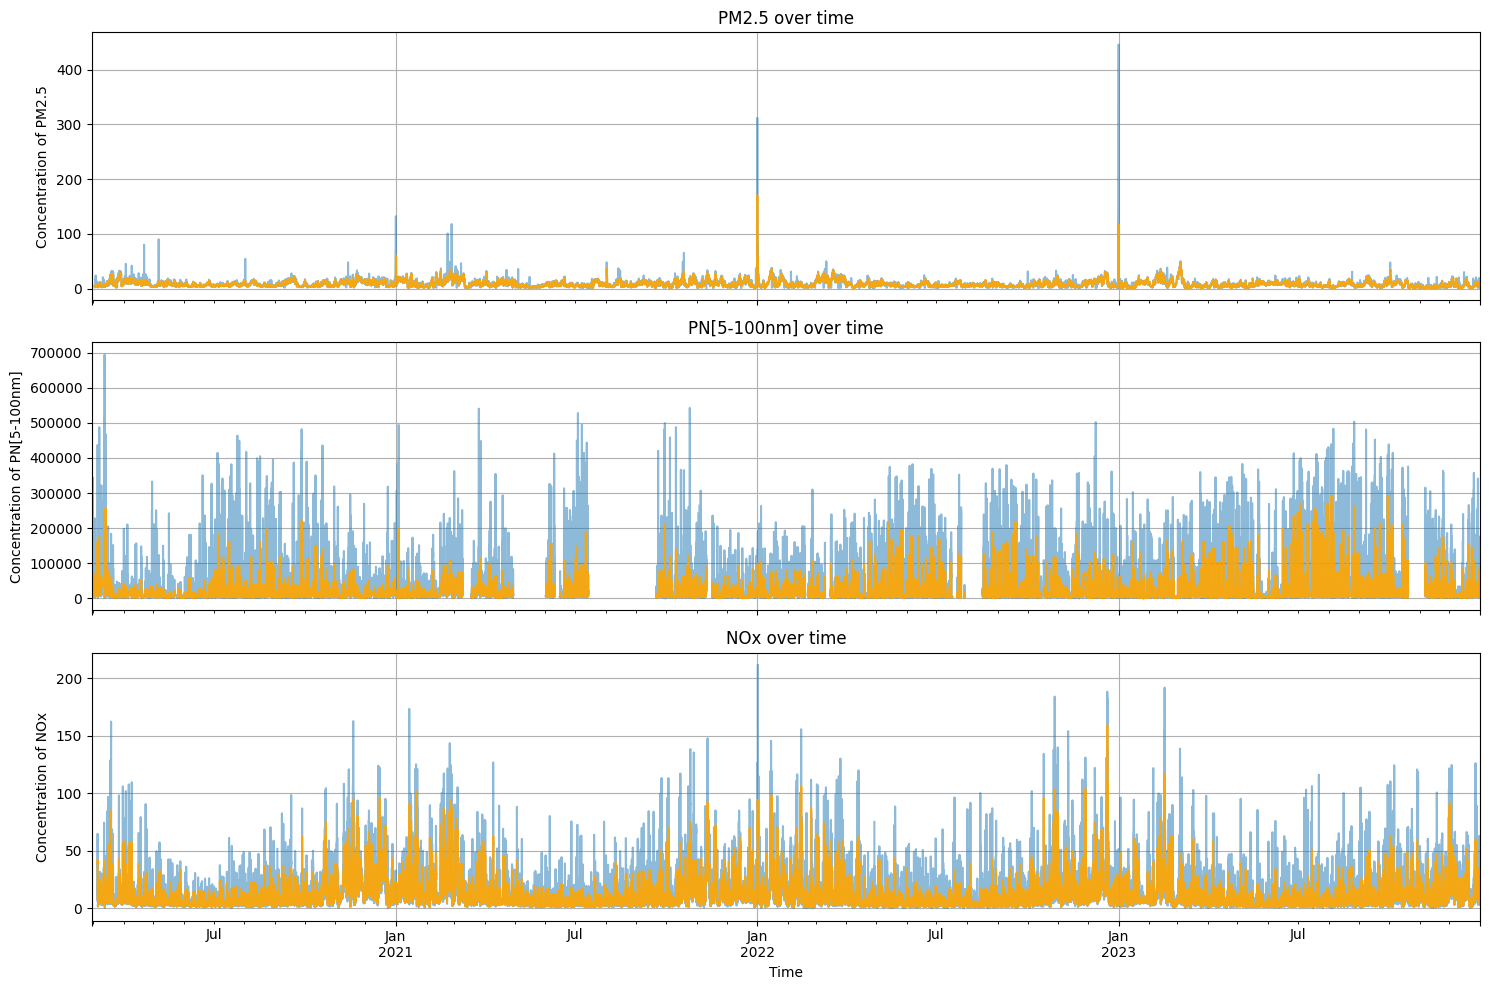

In [268]:

pollutants = ['PM2.5', 'PN[5-100nm]', 'NOx']
# all_pollutants = ['CO2', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'SO2','eBC2.5']
# meteo_pivoted_df[pollutants].plot(figsize=(15,6), alpha=0.8)
# plt.legend(title='Pollutant')

# plt.show()
# for col in pollutants:
#     meteo_pivoted_df[col].plot(figsize=(15,6), alpha=0.8)
#     plt.legend(title='Pollutant')
#     plt.show()

fig, axes = plt.subplots(nrows=len(pollutants), ncols=1, figsize=(15,10), sharex=True)

for i, pollutant in enumerate(pollutants):
    # Original, non-smoothed data
    meteo_pivoted_df[pollutant].plot(ax=axes[i], alpha=0.5, label='Original data')
    # Smoothed line (1-hour rolling average)
    meteo_pivoted_df[pollutant].rolling(window=18, center=True).median().plot(ax=axes[i], alpha=0.9, label='1-day rolling avg', color='orange')

    axes[i].set_title(f'{pollutant} over time')
    axes[i].set_ylabel(f'Concentration of {pollutant}')
    axes[i].grid(True)

plt.xlabel('Time')
plt.tight_layout()
plt.show()

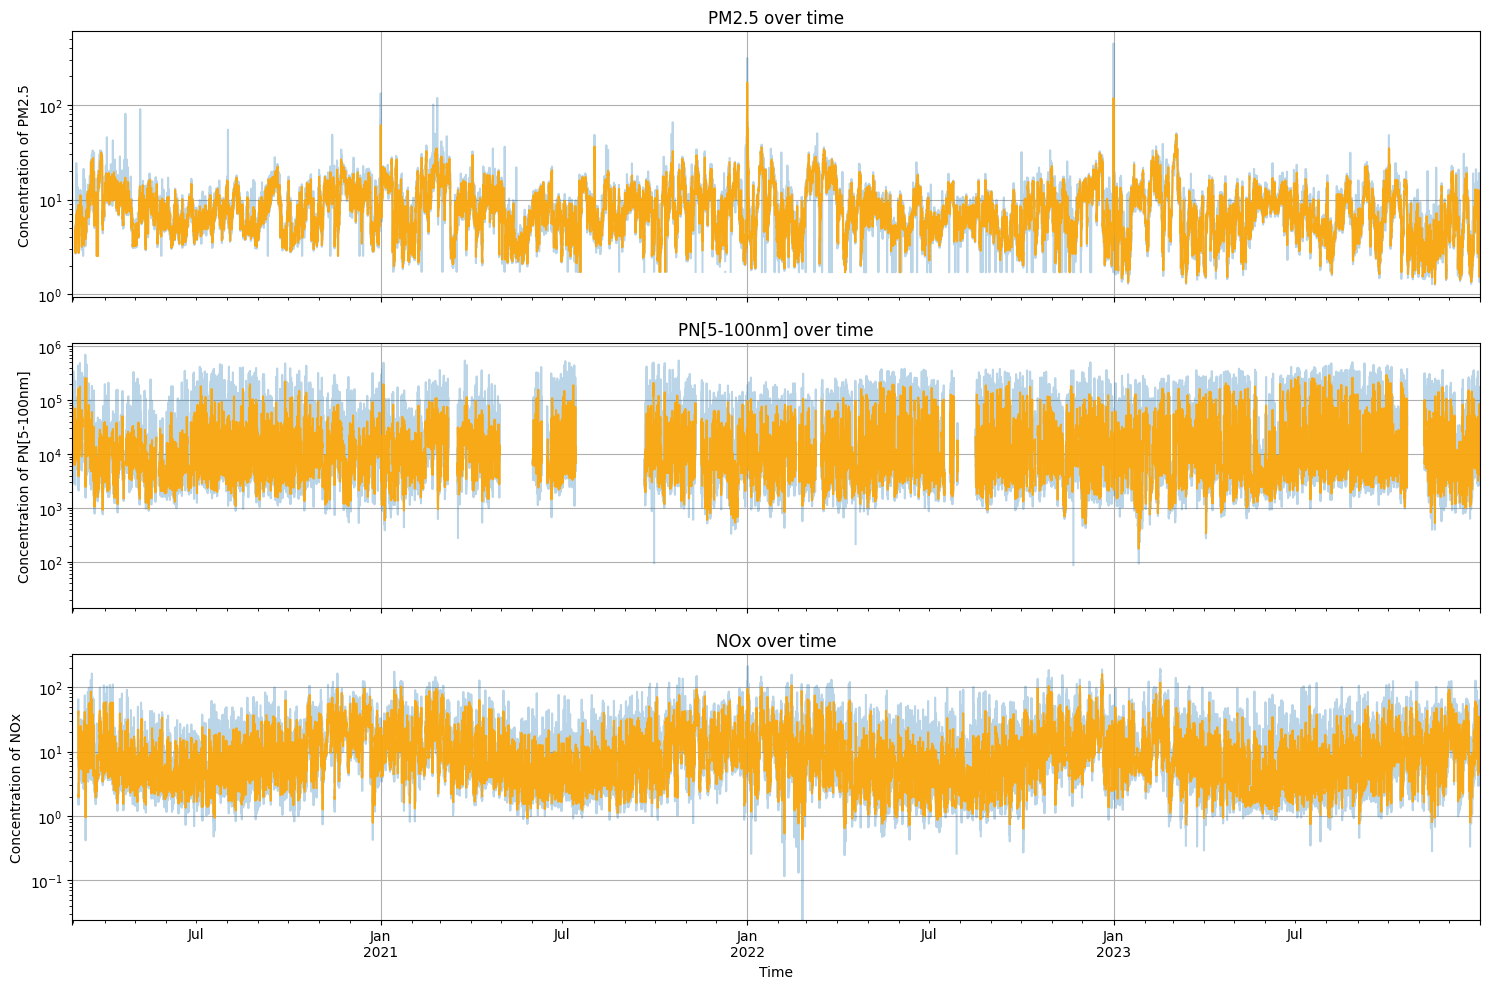

In [164]:
pollutants = ['PM2.5', 'PN[5-100nm]', 'NOx']
# all_pollutants = ['CO2', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'SO2','eBC2.5']
# meteo_pivoted_df[pollutants].plot(figsize=(15,6), alpha=0.8)
# plt.legend(title='Pollutant')

# plt.show()
# for col in pollutants:
#     meteo_pivoted_df[col].plot(figsize=(15,6), alpha=0.8)
#     plt.legend(title='Pollutant')
#     plt.show()

fig, axes = plt.subplots(nrows=len(pollutants), ncols=1, figsize=(15,10), sharex=True)

for i, pollutant in enumerate(pollutants):
    # Original, non-smoothed data
    meteo_pivoted_df[pollutant].plot(ax=axes[i], alpha=0.3, label='Original data', logy=True)

    # Smoothed line (1-hour rolling average)
    meteo_pivoted_df[pollutant].rolling(window=18, center=True).median().plot(ax=axes[i], alpha=0.9, label='1-day rolling avg', color='orange', logy=True)

    axes[i].set_title(f'{pollutant} over time')
    axes[i].set_ylabel(f'Concentration of {pollutant}')
    axes[i].grid(True)

plt.xlabel('Time')
plt.tight_layout()
plt.show()

Initial observations:
- large spikes exactly at the new year --> possible explanation fireworks?

In [167]:
meteo_pivoted_df.groupby(meteo_pivoted_df.index.weekday)['PM2.5'].median()

starttime
0    6.69510
1    7.09824
2    7.20864
3    7.63003
4    7.77738
5    7.53195
6    7.26974
Name: PM2.5, dtype: float64

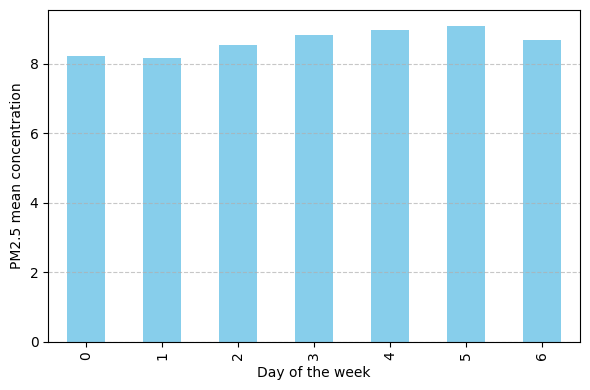

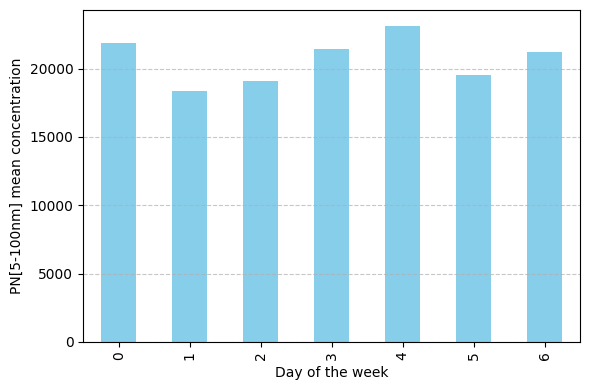

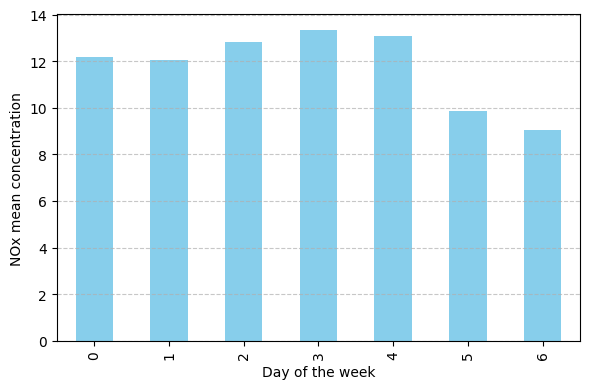

In [168]:
for pollutant in pollutants:
    mean_by_day = meteo_pivoted_df.groupby([meteo_pivoted_df.index.weekday])[pollutant].mean()
    mean_by_day.plot(kind='bar', figsize=(6,4), color='skyblue')
    plt.xlabel('Day of the week')
    plt.ylabel(pollutant+' mean concentration')
    # plt.xticks(rotation=90)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Define seasons

In [169]:
# Define seasons

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

meteo_pivoted_df['season'] = meteo_pivoted_df['month'].map(season_map)

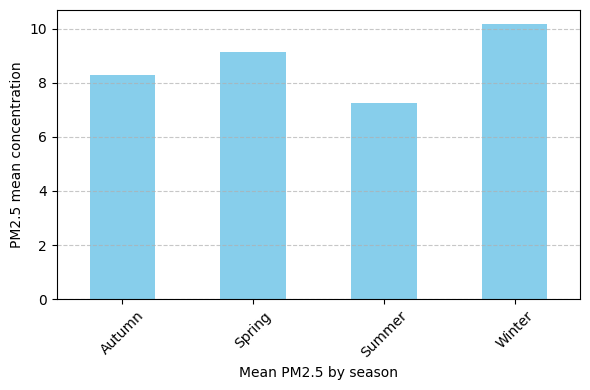

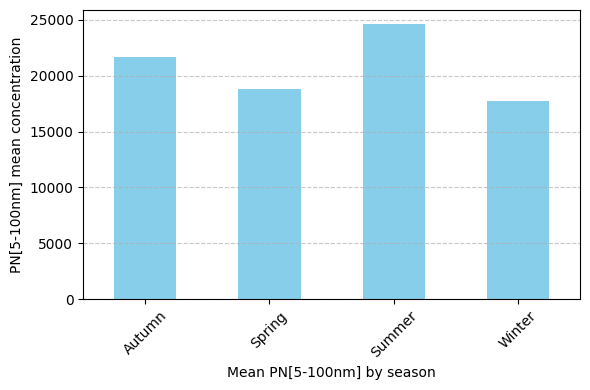

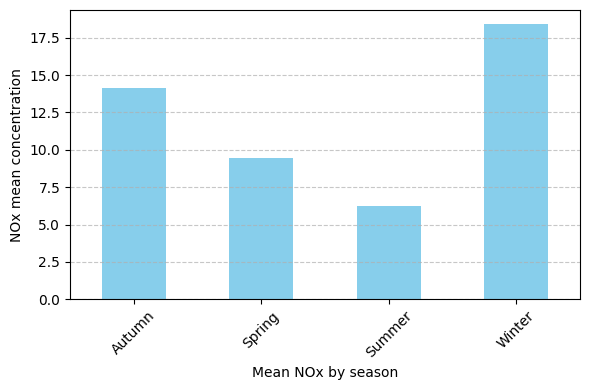

In [170]:
for pollutant in pollutants:
    mean_by_season = meteo_pivoted_df.groupby('season')[pollutant].mean()
    # mean_by_month = meteo_pivoted_df.groupby('month')[pollutant].mean()
    mean_by_season.plot(kind='bar', figsize=(6,4), color='skyblue')
    plt.xlabel('Mean '+ pollutant + ' by season')
    plt.ylabel(pollutant+' mean concentration')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

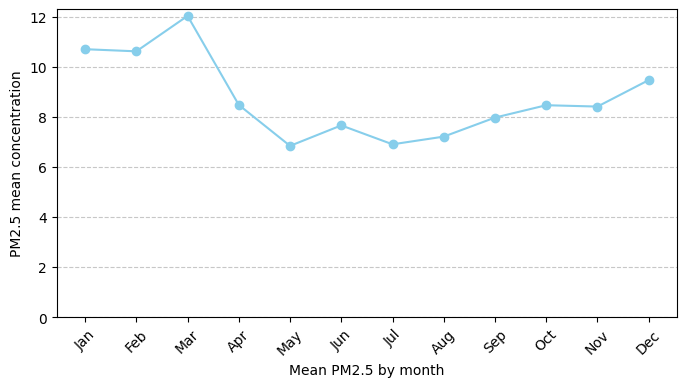

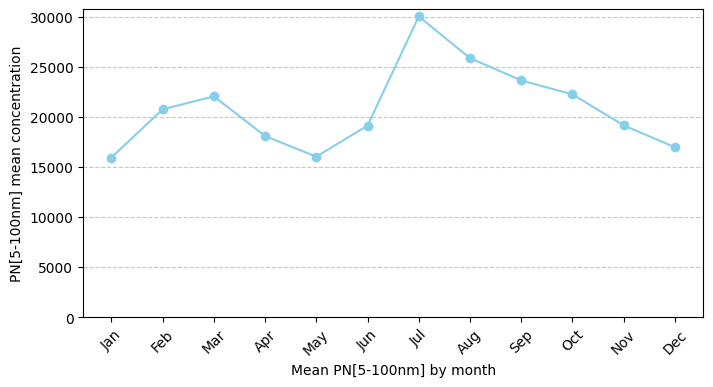

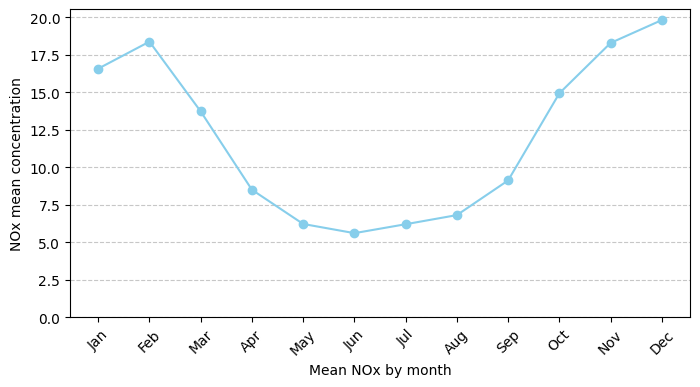

In [171]:
for pollutant in pollutants:
    # mean_by_season = meteo_pivoted_df.groupby('season')[pollutant].mean()
    mean_by_month = meteo_pivoted_df.groupby('month')[pollutant].mean()
    mean_by_month.plot(kind='line', figsize=(8,4), color='skyblue', marker='o')
    plt.xlabel('Mean '+ pollutant + ' by month')
    plt.ylabel(pollutant+' mean concentration')
    plt.xticks(
        rotation=45,
        labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
        ticks=range(1,13)
               )
    plt.ylim(bottom=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plt.tight_layout()
    plt.show()

### Check New Year's eve

For PM2.5 particles, one can clearly see that there is an immediate and huge spike at midnight on New Year's Eve

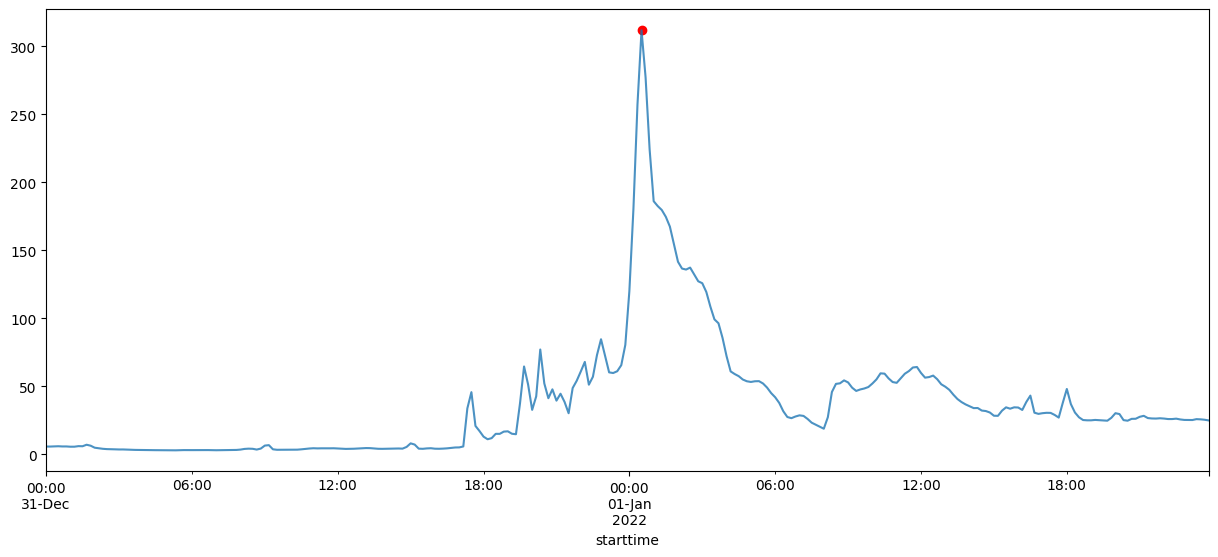

In [172]:
df_new_years_zoom = meteo_pivoted_df['2021-12-31':'2022-01-01']
df_new_years_zoom['PM2.5'].plot(figsize=(15, 6), alpha=0.8)
peak = df_new_years_zoom['PM2.5'].idxmax()
plt.scatter(peak, df_new_years_zoom['PM2.5'].max(), color='red')
plt.show()

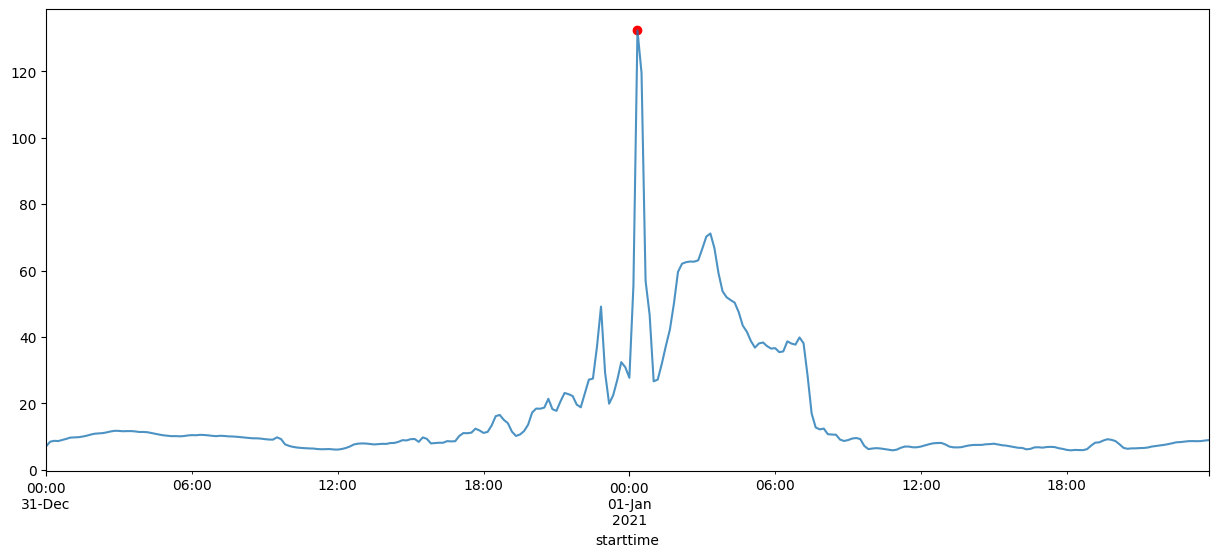

In [173]:
df_new_years_zoom = meteo_pivoted_df['2020-12-31':'2021-01-01']

df_new_years_zoom['PM2.5'].plot(figsize=(15, 6), alpha=0.8)
peak = df_new_years_zoom['PM2.5'].idxmax()
plt.scatter(peak, df_new_years_zoom['PM2.5'].max(), color='red')
plt.show()

Note also that there was significantly less particles on 2020/2021 new year (middle of Omicron wave)

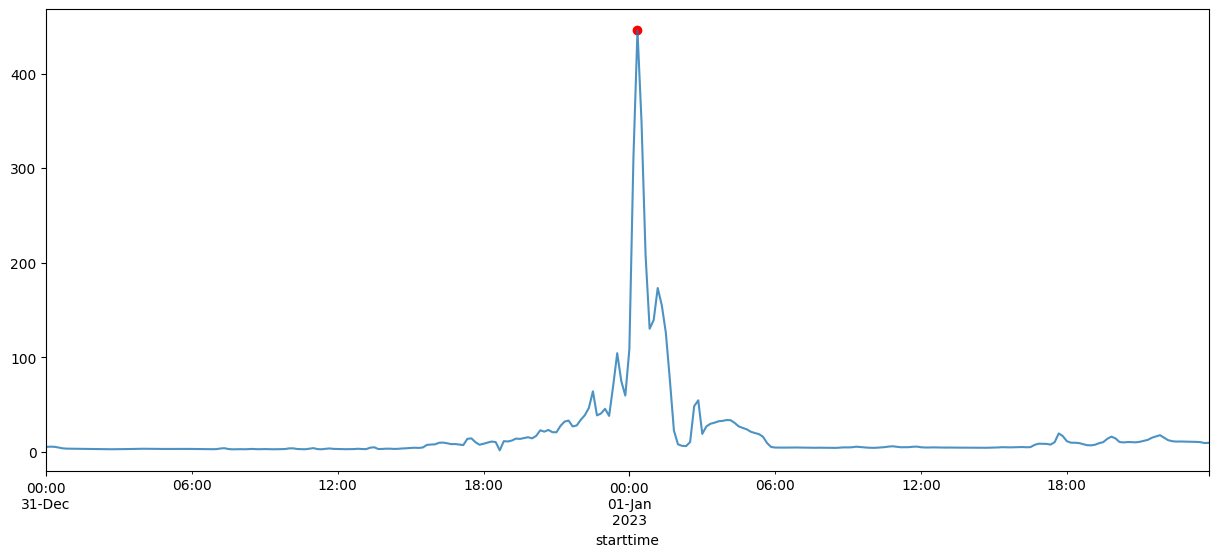

In [174]:
df_new_years_zoom = meteo_pivoted_df['2022-12-31':'2023-01-01']
df_new_years_zoom['PM2.5'].plot(figsize=(15, 6), alpha=0.8)
peak = df_new_years_zoom['PM2.5'].idxmax()
plt.scatter(peak, df_new_years_zoom['PM2.5'].max(), color='red')
plt.show()

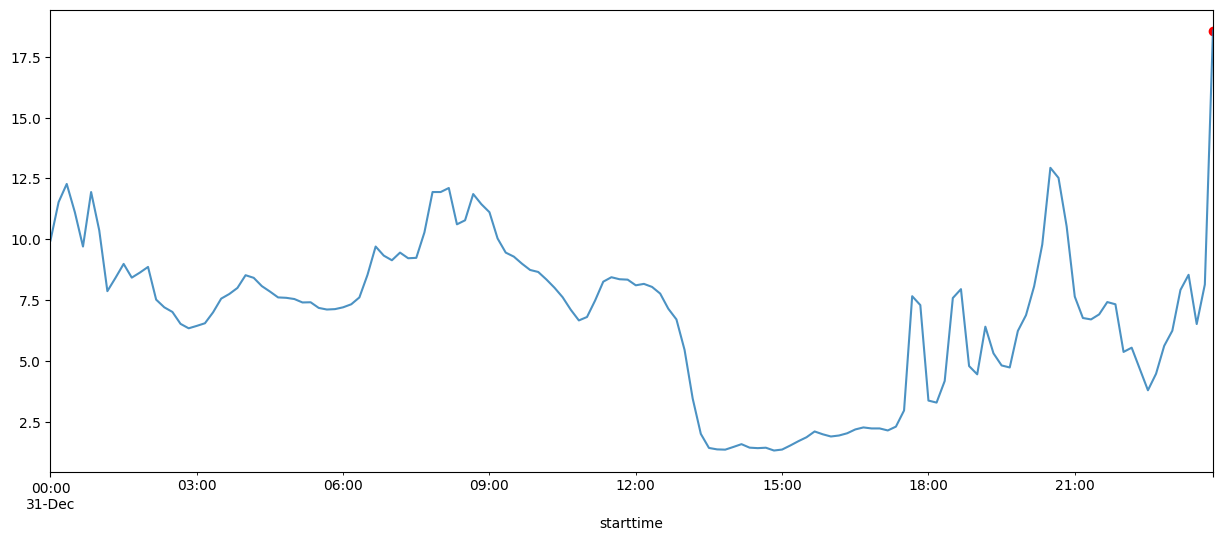

In [175]:
df_new_years_zoom = meteo_pivoted_df['2023-12-31':'2023-12-31']
df_new_years_zoom['PM2.5'].plot(figsize=(15, 6), alpha=0.8)
peak = df_new_years_zoom['PM2.5'].idxmax()
plt.scatter(peak, df_new_years_zoom['PM2.5'].max(), color='red')
plt.show()

# Exploring correlations

In [176]:
meteo_pivoted_df.columns

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5',
       'year', 'month', 'season'],
      dtype='object', name='parameter')

In [177]:
correlation_matrix = meteo_pivoted_df[['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5']].corr()

In [178]:
display(correlation_matrix)

parameter,CO2,Hr,Hr_Trockner,NO,NO2,NOx,PM2.5,PN[5-100nm],RainDur,SO2,StrGlo,T,T_Trockner,WD,WVv,eBC2.5
parameter,,,,,,,,,,,,,,,,
CO2,1.000000,0.509689,-0.016869,0.513471,0.519974,0.581474,0.325491,-0.060328,-0.081686,0.097459,-0.380474,-0.331524,-0.088151,-0.150227,-0.497879,0.605698
Hr,0.509689,1.000000,0.038896,0.220562,0.288938,0.281480,0.036579,-0.083170,0.276431,-0.230916,-0.583520,-0.544651,-0.230375,-0.038194,-0.351632,0.235199
Hr_Trockner,-0.016869,0.038896,1.000000,-0.148560,-0.255215,-0.218575,-0.206837,0.101006,0.052041,-0.100144,0.138483,0.739547,0.015965,0.058108,-0.061402,-0.133914
NO,0.513471,0.220562,-0.148560,1.000000,0.568331,0.917570,0.312148,0.147961,-0.025630,0.476854,-0.034471,-0.245861,-0.104521,0.069151,-0.174697,0.740475
NO2,0.519974,0.288938,-0.255215,0.568331,1.000000,0.848608,0.322700,0.256083,0.038396,0.480419,-0.237840,-0.404701,-0.109955,0.127205,-0.294592,0.685010
NOx,0.581474,0.281480,-0.218575,0.917570,0.848608,1.000000,0.356620,0.218310,0.002081,0.538097,-0.137078,-0.353695,-0.120275,0.105988,-0.254774,0.807282
PM2.5,0.325491,0.036579,-0.206837,0.312148,0.322700,0.356620,1.000000,-0.046655,-0.156639,0.395390,0.005465,-0.192542,0.018517,-0.123698,-0.228754,0.603591
PN[5-100nm],-0.060328,-0.083170,0.101006,0.147961,0.256083,0.218310,-0.046655,1.000000,0.018429,0.328904,0.017707,0.111104,0.016055,0.271848,0.186779,0.128552
RainDur,-0.081686,0.276431,0.052041,-0.025630,0.038396,0.002081,-0.156639,0.018429,1.000000,-0.089092,-0.168080,-0.104306,-0.043154,0.127718,0.082382,-0.073243


In [179]:
display(correlation_matrix['PM2.5'].sort_values(ascending=False))

parameter
PM2.5          1.000000
eBC2.5         0.603591
SO2            0.395390
NOx            0.356620
CO2            0.325491
NO2            0.322700
NO             0.312148
Hr             0.036579
T_Trockner     0.018517
StrGlo         0.005465
PN[5-100nm]   -0.046655
WD            -0.123698
RainDur       -0.156639
T             -0.192542
Hr_Trockner   -0.206837
WVv           -0.228754
Name: PM2.5, dtype: float64

In [180]:
# Add a 'season' column first
meteo_pivoted_df.groupby('season')[['PM2.5', 'T', 'WVv']].corr()

parameter            PM2.5         T       WVv
season parameter                              
Autumn PM2.5      1.000000 -0.039273 -0.311283
       T         -0.039273  1.000000  0.109054
       WVv       -0.311283  0.109054  1.000000
Spring PM2.5      1.000000 -0.194989 -0.244720
       T         -0.194989  1.000000  0.177765
       WVv       -0.244720  0.177765  1.000000
Summer PM2.5      1.000000  0.302567 -0.126942
       T          0.302567  1.000000  0.328515
       WVv       -0.126942  0.328515  1.000000
Winter PM2.5      1.000000 -0.296414 -0.279294
       T         -0.296414  1.000000  0.281251
       WVv       -0.279294  0.281251  1.000000

We see that there is a higher correlation with wind speed in autumn and winter

<Axes: xlabel='hour'>

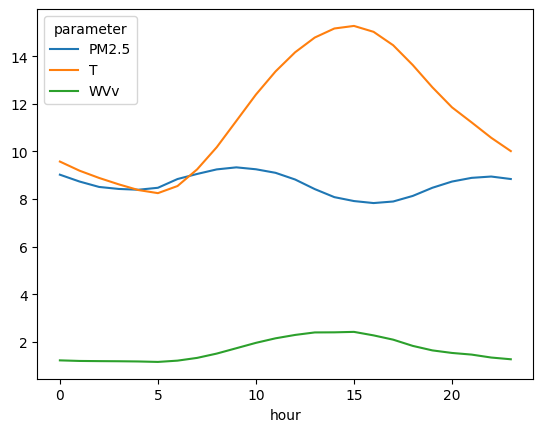

In [184]:
meteo_pivoted_df['hour'] = meteo_pivoted_df.index.hour
meteo_pivoted_df.groupby('hour')[['PM2.5', 'T','WVv']].mean().plot()

In [ ]:
meteo_pivoted_df.groupby('hour')['PM2.5'].mean()

In [185]:
meteo_pivoted_df.groupby('hour')[['PM2.5', 'T', 'WVv']].corr()

parameter          PM2.5         T       WVv
hour parameter                              
0    PM2.5      1.000000 -0.151704 -0.111851
     T         -0.151704  1.000000 -0.058413
     WVv       -0.111851 -0.058413  1.000000
1    PM2.5      1.000000 -0.213918 -0.173274
     T         -0.213918  1.000000 -0.075548
...                  ...       ...       ...
22   T         -0.268881  1.000000 -0.031000
     WVv       -0.236257 -0.031000  1.000000
23   PM2.5      1.000000 -0.271894 -0.229941
     T         -0.271894  1.000000 -0.039120
     WVv       -0.229941 -0.039120  1.000000

[72 rows x 3 columns]

In [186]:
meteo_pivoted_df.groupby('month')[['PM2.5', 'T', 'WVv']].corr()

parameter           PM2.5         T       WVv
month parameter                              
1     PM2.5      1.000000 -0.252969 -0.209593
      T         -0.252969  1.000000  0.305261
      WVv       -0.209593  0.305261  1.000000
2     PM2.5      1.000000 -0.178359 -0.383235
      T         -0.178359  1.000000  0.172034
      WVv       -0.383235  0.172034  1.000000
3     PM2.5      1.000000 -0.122679 -0.320765
      T         -0.122679  1.000000  0.212571
      WVv       -0.320765  0.212571  1.000000
4     PM2.5      1.000000  0.062490 -0.241135
      T          0.062490  1.000000  0.166768
      WVv       -0.241135  0.166768  1.000000
5     PM2.5      1.000000  0.121400 -0.197724
      T          0.121400  1.000000  0.260751
      WVv       -0.197724  0.260751  1.000000
6     PM2.5      1.000000  0.332165 -0.068431
      T          0.332165  1.000000  0.388072
      WVv       -0.068431  0.388072  1.000000
7     PM2.5      1.000000  0.271773 -0.126736
      T          0.271773  1.000000  0.386550
      WVv       -0.126736  0.386550  1.000000
8     PM2.5      1.000000  0.331301 -0.180490
      T          0.331301  1.000000  0.233609
      WVv       -0.180490  0.233609  1.000000
9     PM2.5      1.000000  0.307074 -0.263265
      T          0.307074  1.000000  0.125842
      WVv       -0.263265  0.125842  1.000000
10    PM2.5      1.000000 -0.026832 -0.302278
      T         -0.026832  1.000000  0.289692
      WVv       -0.302278  0.289692  1.000000
11    PM2.5      1.000000 -0.364103 -0.357393
      T         -0.364103  1.000000  0.241956
      WVv       -0.357393  0.241956  1.000000
12    PM2.5      1.000000 -0.555805 -0.371795
      T         -0.555805  1.000000  0.376609
      WVv       -0.371795  0.376609  1.000000

During the colder months, there is a higher correlation of concentration of PM2.5 and WVv

<Axes: xlabel='PM2.5'>

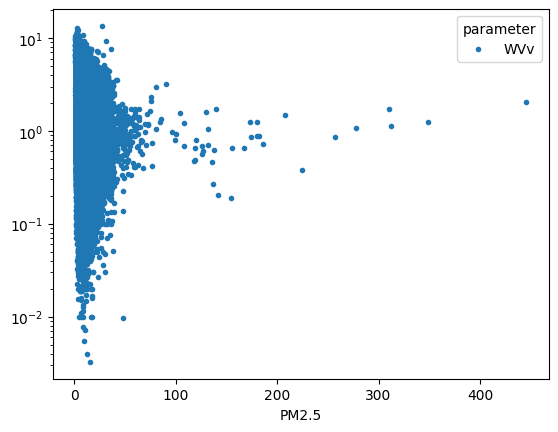

In [220]:
meteo_pivoted_df.plot(x='PM2.5',y=['WVv'],style='.',logy=True)

<Axes: xlabel='starttime'>

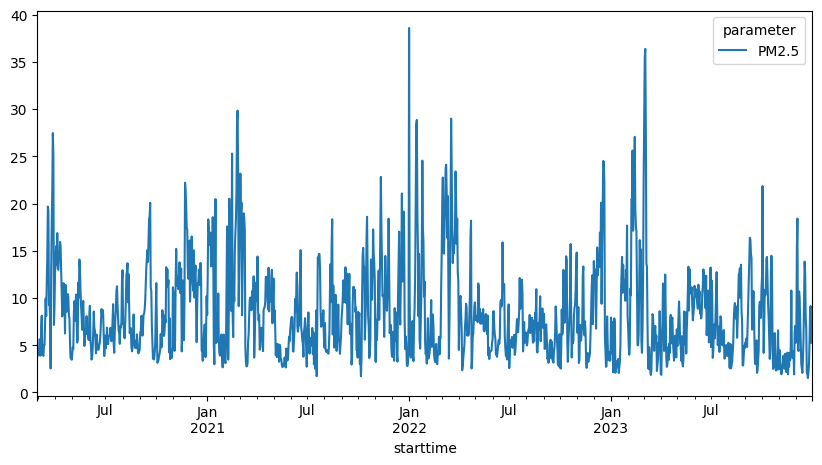

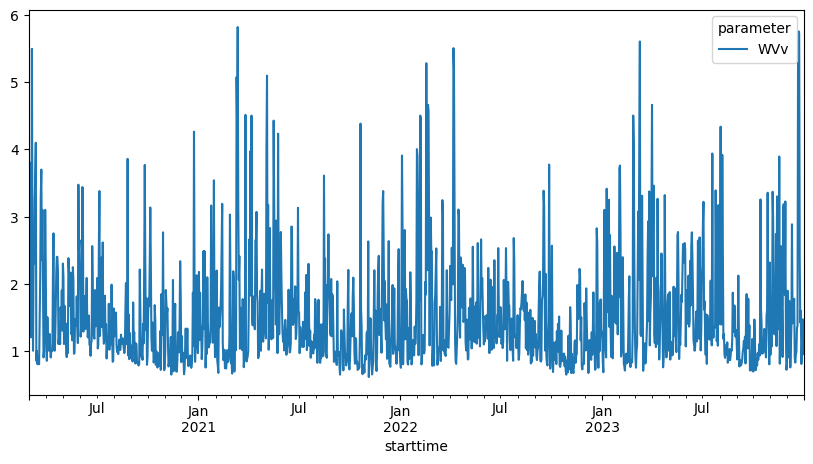

In [232]:
meteo_pivoted_df[['PM2.5']].resample('D').median().plot(style='-', figsize=(10,5))

meteo_pivoted_df[['WVv']].resample('D').median().plot(style='-', figsize=(10,5))


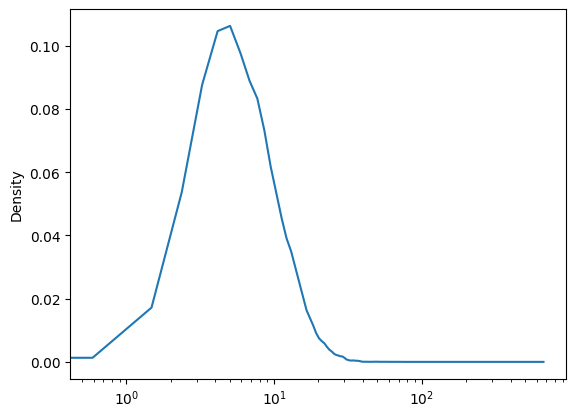

In [ ]:
meteo_pivoted_df['PM2.5'].log.plot.kde()
plt.xscale('log')

Text(0.5, 1.0, 'Missing Values Bar Chart')

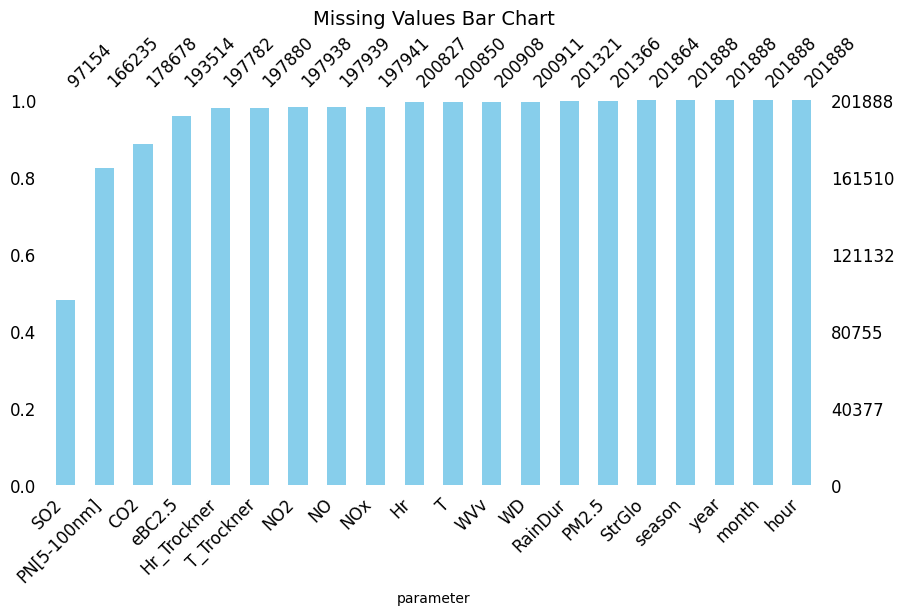

In [267]:


import missingno

missingno.bar(meteo_pivoted_df, figsize=(10, 5), 
              fontsize=12, 
              sort='ascending', 
              color='skyblue', 
              labels=True, 
              label_rotation=45)
plt.title('Missing Values Bar Chart', fontsize=14)

In [266]:
meteo_pivoted_df.shape

(201888, 20)

Text(0.5, 1.0, 'Missing Values Matrix')

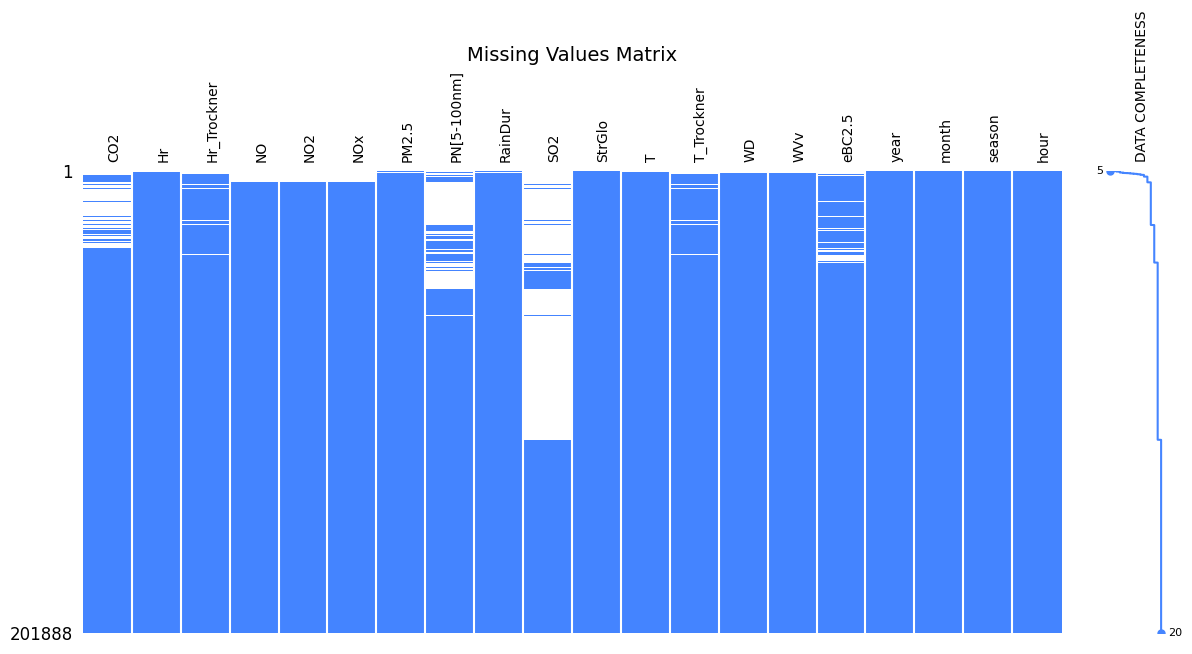

In [264]:
# Showing the distribution of missing values

missingno.matrix(meteo_pivoted_df,
                 figsize=(14,6), 
                 fontsize=10, 
                 sort='ascending', 
                 color=(0.27, 0.52, 1.0),
                 sparkline=True,
                 labels=True, 
                 label_rotation=90)

plt.title('Missing Values Matrix', fontsize=14)

Text(0.5, 1.0, 'Missing Values Heatmap')

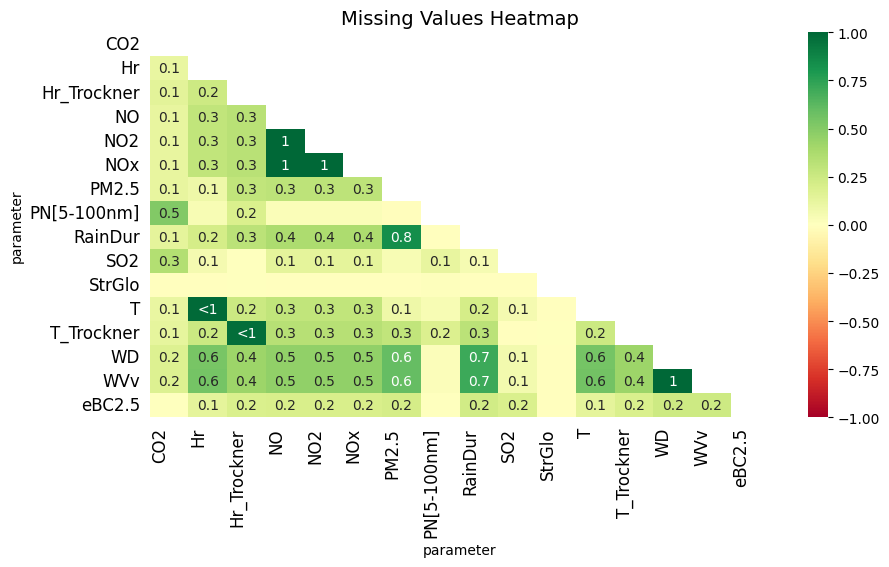

In [260]:
missingno.heatmap(meteo_pivoted_df, 
                  figsize=(10,5), 
                  fontsize=12,
                  cmap='RdYlGn',
                  labels=True,
                  label_rotation=90,)

plt.title('Missing Values Heatmap', fontsize=14)


Text(0.5, 1.0, 'Missing Values Dendrogram')

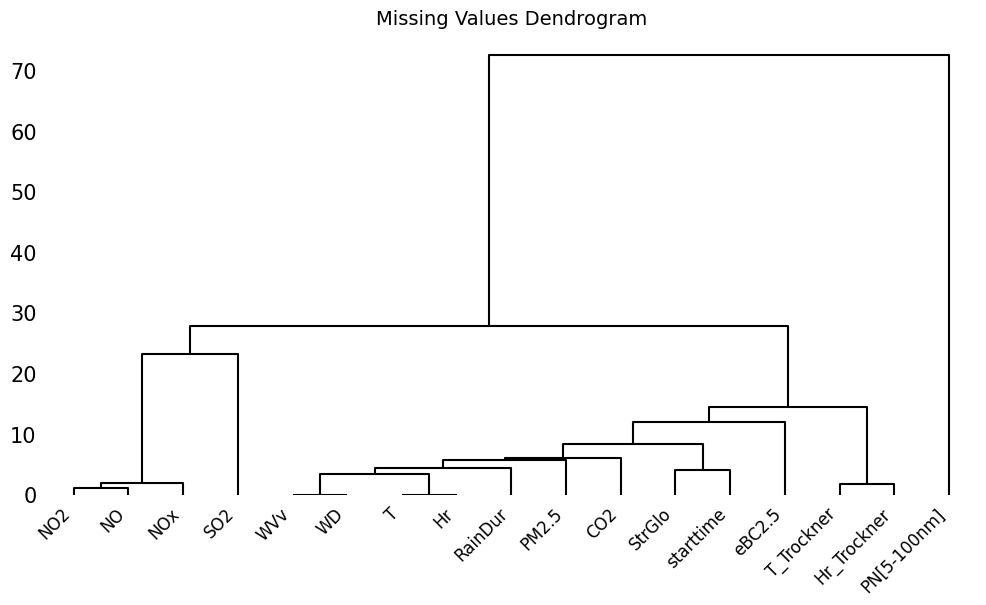

In [261]:
missingno.dendrogram(df, 
                     figsize=(12,6), 
                     fontsize=12, 
                     orientation="top", # top, right, bottom, left
                     method="average") # single, complete, average, weighted, centroid, median, ward


plt.title('Missing Values Dendrogram', fontsize=14)